## 560. 和为 K 的子数组

给你一个整数数组 nums 和一个整数 k ，请你统计并返回 该数组中和为 k 的子数组的个数 。
子数组是数组中元素的连续非空序列

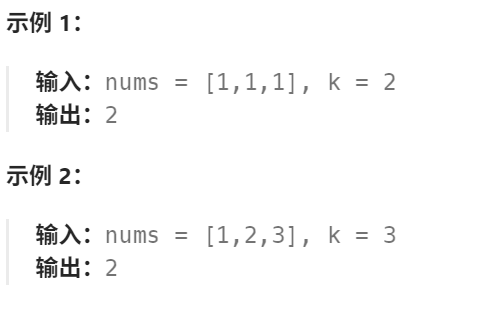


核心思路

该算法基于前缀和 + 哈希表。用 preSum 表示从数组起点到当前位置的累加和，若某一段连续子数组的和为 k，则必然存在两个前缀和满足
preSum[j] − preSum[i] = k。因此，在遍历数组时，只需统计此前出现过多少次值为 preSum − k 的前缀和，即可直接累加得到以当前位置结尾、和为 k 的子数组个数。哈希表用于记录每个前缀和出现的次数，从而将原本需要双重循环的问题转化为一次线性扫描。

In [1]:
class Solution:
    def subarraySum(self, nums, k):
        """
        统计和为k的连续子数组个数
        :param nums: 整数数组（可含正、负、0）
        :param k: 目标和
        :return: 满足条件的子数组个数
        """
        preSum = 0  # 记录当前前缀和，单变量累加无需数组
        ans = 0     # 最终答案，统计子数组个数
        # 哈希表：键=前缀和，值=该前缀和出现的次数；初始{0:1}处理preSum=k的情况
        prefix_count = {0: 1}
        
        for num in nums:
            preSum += num  # 累加当前元素，更新前缀和
            # 核心：查询preSum-k的出现次数，累加到答案，注意是preSum-k而非k-preSum
            if (preSum - k) in prefix_count:
                ans += prefix_count[preSum - k]
            # 更新哈希表：当前preSum的出现次数+1
            prefix_count[preSum] = prefix_count.get(preSum, 0) + 1
        
        return ans
nums = [1, 2, 3]
k = 3

print(Solution().subarraySum(nums, k))


2


复杂度分析：

算法仅对数组进行一次遍历，每个元素只涉及常数次哈希表查询与更新操作，因此时间复杂度为 O(n)。空间上，哈希表在最坏情况下可能存储 n 个不同的前缀和，故空间复杂度为 O(n)。

---